In [7]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson  

# Define what times you want to see
time_0 = '000000' 
time_aft = '001750' # Ojo: Asegúrate que este sea el tiempo final correcto

# Rutas (Ajusta si es necesario)
base_path = '/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/rf_big/MS/FLD/'
file_e2_0   = base_path + 'e2/e2-' + time_0 + '.h5'
file_e2_aft = base_path + 'e2/e2-' + time_aft + '.h5'
# AGREGAMOS B3
file_b3_0   = base_path + 'b3/b3-' + time_0 + '.h5'
file_b3_aft = base_path + 'b3/b3-' + time_aft + '.h5'

# --- FUNCIÓN DE LECTURA SEGURA ---
def get_field(path, field_name):
    with h5py.File(path, "r") as f:
        return np.copy(f[field_name])

# Cargar Campos Eléctricos
E_inc = get_field(file_e2_0, 'e2')
E_aft = get_field(file_e2_aft, 'e2')

# Cargar Campos Magnéticos (¡LA CLAVE!)
B_inc = get_field(file_b3_0, 'b3')
B_aft = get_field(file_b3_aft, 'b3')

# Obtener eje X
with h5py.File(file_e2_0, "r") as f:
    x_bounds = f['AXIS/AXIS1'][:]
    
x_size = x_bounds[1] - x_bounds[0]
dx = x_size/len(E_inc)
x = np.linspace(x_bounds[0], x_bounds[1], len(E_inc))

# --- Total energy density (U = E^2 + B^2) ---
# En unidades normalizadas de OSIRIS, U = (E^2 + B^2)/2. 
# Como haremos ratios, el /2 se cancela, basta sumar cuadrados.
U_density_inc = E_inc**2 + B_inc**2
U_density_aft = E_aft**2 + B_aft**2

# --- Masks ---
mask_inc   = (x > 0.0) & (x < 110) 
mask_ref   = (x > 0.0) & (x < 70.01)
mask_plasma= (x >= 70.01 ) & (x <= 70.02) # El Limbo
mask_trans = (x > 70.02) & (x < 110)

# --- INTEGRATION ---
# TOTAL INCIDENT WAVE ENERGY
Total_Inc = simpson(y=U_density_inc[mask_inc], dx=dx)

# Final energies (Using E^2 + B^2)
Total_Ref = simpson(y=U_density_aft[mask_ref], dx=dx)
Total_Trans = simpson(y=U_density_aft[mask_trans], dx=dx)
Total_Trapped = simpson(y=U_density_aft[mask_plasma], dx=dx)

# --- RESULTS---
R = Total_Ref / Total_Inc
T = Total_Trans / Total_Inc
Trapped = Total_Trapped / Total_Inc
Loss = 1.0 - (R + T + Trapped)

print("=" * 40)
print("For d=0.01 and rise 20 and fall 20")
print(f"REFLECTANCE (R):     {R:.4f}  ({R*100:.2f}%)")
print(f"TRANSMITTANCE (T):    {T:.4f}  ({T*100:.2f}%)")
print(f"ENERGY INSIDE PLASMA:    {Trapped:.4f}  ({Trapped*100:.2f}%)")
print("-" * 40)
print(f"TOTAL SUM:           {R+T+Trapped:.4f}  ({(R+T+Trapped)*100:.2f}%)")
print(f"ABSORPTION (Kin): {Loss:.4f}  ({Loss*100:.2f}%)")
print("=" * 40)

For d=0.01 and rise 20 and fall 20
REFLECTANCE (R):     0.9903  (99.03%)
TRANSMITTANCE (T):    0.0073  (0.73%)
ENERGY INSIDE PLASMA:    0.0000  (0.00%)
----------------------------------------
TOTAL SUM:           0.9976  (99.76%)
ABSORPTION (Kin): 0.0024  (0.24%)


In [6]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson  

# Define what times you want to see
time_0 = '000000' 
time_aft = '001190' # Ojo: Asegúrate que este sea el tiempo final correcto

# Rutas (Ajusta si es necesario)
base_path = '/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/rf_small/MS/FLD/'
file_e2_0   = base_path + 'e2/e2-' + time_0 + '.h5'
file_e2_aft = base_path + 'e2/e2-' + time_aft + '.h5'
# AGREGAMOS B3
file_b3_0   = base_path + 'b3/b3-' + time_0 + '.h5'
file_b3_aft = base_path + 'b3/b3-' + time_aft + '.h5'

# --- FUNCIÓN DE LECTURA SEGURA ---
def get_field(path, field_name):
    with h5py.File(path, "r") as f:
        return np.copy(f[field_name])

# Cargar Campos Eléctricos
E_inc = get_field(file_e2_0, 'e2')
E_aft = get_field(file_e2_aft, 'e2')

# Cargar Campos Magnéticos (¡LA CLAVE!)
B_inc = get_field(file_b3_0, 'b3')
B_aft = get_field(file_b3_aft, 'b3')

# Obtener eje X
with h5py.File(file_e2_0, "r") as f:
    x_bounds = f['AXIS/AXIS1'][:]
    
x_size = x_bounds[1] - x_bounds[0]
dx = x_size/len(E_inc)
x = np.linspace(x_bounds[0], x_bounds[1], len(E_inc))

# --- Total energy density (U = E^2 + B^2) ---
# En unidades normalizadas de OSIRIS, U = (E^2 + B^2)/2. 
# Como haremos ratios, el /2 se cancela, basta sumar cuadrados.
U_density_inc = E_inc**2 + B_inc**2
U_density_aft = E_aft**2 + B_aft**2

# --- Masks ---
mask_inc   = (x > 0.0) & (x < 110) 
mask_ref   = (x > 0.0) & (x < 70.01)
mask_plasma= (x >= 70.01 ) & (x <= 70.02) # El Limbo
mask_trans = (x > 70.02) & (x < 110)

# --- INTEGRATION ---
# TOTAL INCIDENT WAVE ENERGY
Total_Inc = simpson(y=U_density_inc[mask_inc], dx=dx)

# Final energies (Using E^2 + B^2)
Total_Ref = simpson(y=U_density_aft[mask_ref], dx=dx)
Total_Trans = simpson(y=U_density_aft[mask_trans], dx=dx)
Total_Trapped = simpson(y=U_density_aft[mask_plasma], dx=dx)

# --- RESULTS---
R = Total_Ref / Total_Inc
T = Total_Trans / Total_Inc
Trapped = Total_Trapped / Total_Inc
Loss = 1.0 - (R + T + Trapped)

print("=" * 40)
print("For d=0.01 and rise 10 and fall 10")
print(f"REFLECTANCE (R):     {R:.4f}  ({R*100:.2f}%)")
print(f"TRANSMITTANCE (T):    {T:.4f}  ({T*100:.2f}%)")
print(f"ENERGY INSIDE PLASMA:    {Trapped:.4f}  ({Trapped*100:.2f}%)")
print("-" * 40)
print(f"TOTAL SUM:           {R+T+Trapped:.4f}  ({(R+T+Trapped)*100:.2f}%)")
print(f"ABSORPTION (Kin): {Loss:.4f}  ({Loss*100:.2f}%)")
print("=" * 40)

For d=0.01 and rise 10 and fall 10
REFLECTANCE (R):     0.9904  (99.04%)
TRANSMITTANCE (T):    0.0094  (0.94%)
ENERGY INSIDE PLASMA:    0.0000  (0.00%)
----------------------------------------
TOTAL SUM:           0.9999  (99.99%)
ABSORPTION (Kin): 0.0001  (0.01%)


In [1]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson  

# Define what times you want to see
time_0 = '000000' 
time_aft = '001750' # Ojo: Asegúrate que este sea el tiempo final correcto

# Rutas (Ajusta si es necesario)
base_path = '/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/double particles/MS/FLD/'
file_e2_0   = base_path + 'e2/e2-' + time_0 + '.h5'
file_e2_aft = base_path + 'e2/e2-' + time_aft + '.h5'
# AGREGAMOS B3
file_b3_0   = base_path + 'b3/b3-' + time_0 + '.h5'
file_b3_aft = base_path + 'b3/b3-' + time_aft + '.h5'

# --- FUNCIÓN DE LECTURA SEGURA ---
def get_field(path, field_name):
    with h5py.File(path, "r") as f:
        return np.copy(f[field_name])

# Cargar Campos Eléctricos
E_inc = get_field(file_e2_0, 'e2')
E_aft = get_field(file_e2_aft, 'e2')

# Cargar Campos Magnéticos (¡LA CLAVE!)
B_inc = get_field(file_b3_0, 'b3')
B_aft = get_field(file_b3_aft, 'b3')

# Obtener eje X
with h5py.File(file_e2_0, "r") as f:
    x_bounds = f['AXIS/AXIS1'][:]
    
x_size = x_bounds[1] - x_bounds[0]
dx = x_size/len(E_inc)
x = np.linspace(x_bounds[0], x_bounds[1], len(E_inc))

# --- Total energy density (U = E^2 + B^2) ---
# En unidades normalizadas de OSIRIS, U = (E^2 + B^2)/2. 
# Como haremos ratios, el /2 se cancela, basta sumar cuadrados.
U_density_inc = E_inc**2 + B_inc**2
U_density_aft = E_aft**2 + B_aft**2

# --- Masks ---
mask_inc   = (x > 0.0) & (x < 110) 
mask_ref   = (x > 0.0) & (x < 70.01)
mask_plasma= (x >= 70.01 ) & (x <= 70.02) # El Limbo
mask_trans = (x > 70.02) & (x < 110)

# --- INTEGRATION ---
# TOTAL INCIDENT WAVE ENERGY
Total_Inc = simpson(y=U_density_inc[mask_inc], dx=dx)

# Final energies (Using E^2 + B^2)
Total_Ref = simpson(y=U_density_aft[mask_ref], dx=dx)
Total_Trans = simpson(y=U_density_aft[mask_trans], dx=dx)
Total_Trapped = simpson(y=U_density_aft[mask_plasma], dx=dx)

# --- RESULTS---
R = Total_Ref / Total_Inc
T = Total_Trans / Total_Inc
Trapped = Total_Trapped / Total_Inc
Loss = 1.0 - (R + T + Trapped)

print("=" * 40)
print("For d=0.01 and rise 20 and fall 20 but double particle number")
print(f"REFLECTANCE (R):     {R:.4f}  ({R*100:.2f}%)")
print(f"TRANSMITTANCE (T):    {T:.4f}  ({T*100:.2f}%)")
print(f"ENERGY INSIDE PLASMA:    {Trapped:.4f}  ({Trapped*100:.2f}%)")
print("-" * 40)
print(f"TOTAL SUM:           {R+T+Trapped:.4f}  ({(R+T+Trapped)*100:.2f}%)")
print(f"ABSORPTION (Kin): {Loss:.4f}  ({Loss*100:.2f}%)")
print("=" * 40)

For d=0.01 and rise 20 and fall 20 but double particle number
REFLECTANCE (R):     0.9903  (99.03%)
TRANSMITTANCE (T):    0.0073  (0.73%)
ENERGY INSIDE PLASMA:    0.0000  (0.00%)
----------------------------------------
TOTAL SUM:           0.9976  (99.76%)
ABSORPTION (Kin): 0.0024  (0.24%)


In [3]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson  

# Define what times you want to see
time_0 = '000000' 
time_aft = '001750' # Ojo: Asegúrate que este sea el tiempo final correcto

# Rutas (Ajusta si es necesario)
base_path = '/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/lower_ponderomotive/MS/FLD/'
file_e2_0   = base_path + 'e2/e2-' + time_0 + '.h5'
file_e2_aft = base_path + 'e2/e2-' + time_aft + '.h5'
# AGREGAMOS B3
file_b3_0   = base_path + 'b3/b3-' + time_0 + '.h5'
file_b3_aft = base_path + 'b3/b3-' + time_aft + '.h5'

# --- FUNCIÓN DE LECTURA SEGURA ---
def get_field(path, field_name):
    with h5py.File(path, "r") as f:
        return np.copy(f[field_name])

# Cargar Campos Eléctricos
E_inc = get_field(file_e2_0, 'e2')
E_aft = get_field(file_e2_aft, 'e2')

# Cargar Campos Magnéticos (¡LA CLAVE!)
B_inc = get_field(file_b3_0, 'b3')
B_aft = get_field(file_b3_aft, 'b3')

# Obtener eje X
with h5py.File(file_e2_0, "r") as f:
    x_bounds = f['AXIS/AXIS1'][:]
    
x_size = x_bounds[1] - x_bounds[0]
dx = x_size/len(E_inc)
x = np.linspace(x_bounds[0], x_bounds[1], len(E_inc))

# --- Total energy density (U = E^2 + B^2) ---
# En unidades normalizadas de OSIRIS, U = (E^2 + B^2)/2. 
# Como haremos ratios, el /2 se cancela, basta sumar cuadrados.
U_density_inc = E_inc**2 + B_inc**2
U_density_aft = E_aft**2 + B_aft**2

# --- Masks ---
mask_inc   = (x > 0.0) & (x < 110) 
mask_ref   = (x > 0.0) & (x < 70.01)
mask_plasma= (x >= 70.01 ) & (x <= 70.02) # El Limbo
mask_trans = (x > 70.02) & (x < 110)

# --- INTEGRATION ---
# TOTAL INCIDENT WAVE ENERGY
Total_Inc = simpson(y=U_density_inc[mask_inc], dx=dx)

# Final energies (Using E^2 + B^2)
Total_Ref = simpson(y=U_density_aft[mask_ref], dx=dx)
Total_Trans = simpson(y=U_density_aft[mask_trans], dx=dx)
Total_Trapped = simpson(y=U_density_aft[mask_plasma], dx=dx)

# --- RESULTS---
R = Total_Ref / Total_Inc
T = Total_Trans / Total_Inc
Trapped = Total_Trapped / Total_Inc
Loss = 1.0 - (R + T + Trapped)

print("=" * 40)
print("For d=0.01 and rise 20 and fall 20 but 100 times lower ponderomotive")
print(f"REFLECTANCE (R):     {R:.4f}  ({R*100:.2f}%)")
print(f"TRANSMITTANCE (T):    {T:.4f}  ({T*100:.2f}%)")
print(f"ENERGY INSIDE PLASMA:    {Trapped:.4f}  ({Trapped*100:.2f}%)")
print("-" * 40)
print(f"TOTAL SUM:           {R+T+Trapped:.4f}  ({(R+T+Trapped)*100:.2f}%)")
print(f"ABSORPTION (Kin): {Loss:.4f}  ({Loss*100:.2f}%)")
print("=" * 40)

For d=0.01 and rise 20 and fall 20 but 100 times lower ponderomotive
REFLECTANCE (R):     0.9907  (99.07%)
TRANSMITTANCE (T):    0.0071  (0.71%)
ENERGY INSIDE PLASMA:    0.0000  (0.00%)
----------------------------------------
TOTAL SUM:           0.9978  (99.78%)
ABSORPTION (Kin): 0.0022  (0.22%)


<>:78: SyntaxWarning: invalid escape sequence '\o'
<>:78: SyntaxWarning: invalid escape sequence '\o'
/var/folders/r1/8fnw2qyd6vs6x4fvg2cghqzh0000gn/T/ipykernel_4002/2291269566.py:78: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Time $[1/\omega_p]$')


Leyendo archivos de Poynting (esto tomará unos segundos)...
INTEGRACIÓN POR FLUJO DE POYNTING (Independiente de la caja)
REFLECTANCIA (R):     0.9904  (99.04%)
TRANSMITANCIA (T):    0.0094  (0.94%)
--------------------------------------------------
SUMA TOTAL (R+T):     0.9998  (99.98%)
ABSORCIÓN (Real):     0.0002  (0.02%)


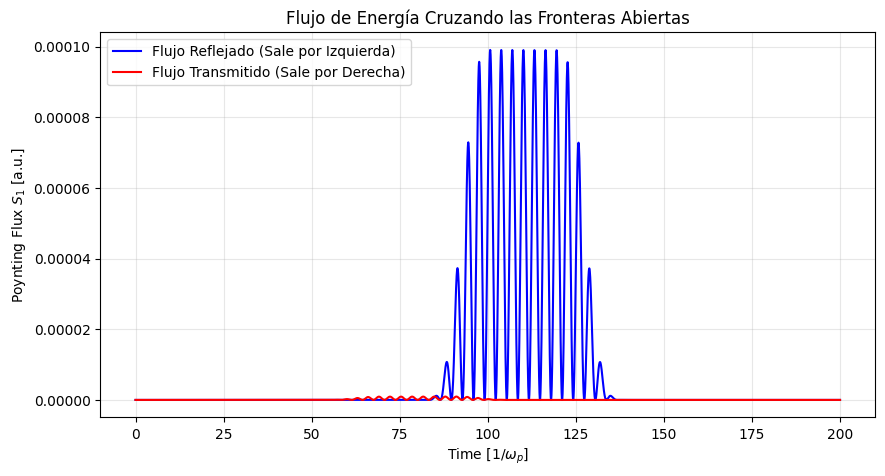

In [4]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson

# Ruta base a tus diagnósticos
base_path = '/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/rf_big/MS/FLD/'

# ====================================================================
# 1. CALCULAR ENERGÍA INCIDENTE (Integral Espacial en t=0)
# ====================================================================
file_e2_0 = base_path + 'e2/e2-000000.h5'
file_b3_0 = base_path + 'b3/b3-000000.h5'

with h5py.File(file_e2_0, "r") as f:
    E_inc = np.copy(f['e2'])
    x_bounds = f['AXIS/AXIS1'][:]

with h5py.File(file_b3_0, "r") as f:
    B_inc = np.copy(f['b3'])

dx = (x_bounds[1] - x_bounds[0]) / len(E_inc)

# FACTOR CRÍTICO: 0.5 para que empate con el flujo de Poynting
U_density_inc = 0.5 * (E_inc**2 + B_inc**2)
Total_Inc = simpson(y=U_density_inc, dx=dx)


# ====================================================================
# 2. CALCULAR ENERGÍA REFLEJADA Y TRANSMITIDA (Integral Temporal de S1)
# ====================================================================
num_files = 5001
dt_dump = 0.04 # Tiempo físico entre cada archivo
time_array = np.linspace(0, (num_files-1)*dt_dump, num_files)

s1_left = np.zeros(num_files)
s1_right = np.zeros(num_files)

print("Leyendo archivos de Poynting (esto tomará unos segundos)...")
for i in range(num_files):
    # Generar nombre del archivo con 6 dígitos
    filename = base_path + f's1/s1-{i:06d}.h5'
    try:
        with h5py.File(filename, "r") as f:
            s1_data = f['s1'][:]
            # Extraer solo el valor en las fronteras
            s1_left[i] = s1_data[0]       # x = 0
            s1_right[i] = s1_data[-1]     # x = 110
    except Exception as e:
        print(f"Error leyendo {filename}. Saltando...")
        break

# Integración en el tiempo usando simpson y dt_dump
Total_Ref = simpson(y=-s1_left, dx=dt_dump)
Total_Trans = simpson(y=s1_right, dx=dt_dump)


# ====================================================================
# 3. RESULTADOS
# ====================================================================
R = Total_Ref / Total_Inc
T = Total_Trans / Total_Inc
Loss = 1.0 - (R + T)

print("=" * 50)
print("INTEGRACIÓN POR FLUJO DE POYNTING (Independiente de la caja)")
print(f"REFLECTANCIA (R):     {R:.4f}  ({R*100:.2f}%)")
print(f"TRANSMITANCIA (T):    {T:.4f}  ({T*100:.2f}%)")
print("-" * 50)
print(f"SUMA TOTAL (R+T):     {R+T:.4f}  ({(R+T)*100:.2f}%)")
print(f"ABSORCIÓN (Real):     {Loss:.4f}  ({Loss*100:.2f}%)")
print("=" * 50)

# Graficar los pulsos cruzando las fronteras
plt.figure(figsize=(10, 5))
plt.plot(time_array, -s1_left, label='Flujo Reflejado (Sale por Izquierda)', color='blue')
plt.plot(time_array, s1_right, label='Flujo Transmitido (Sale por Derecha)', color='red')
plt.xlabel('Time $[1/\omega_p]$')
plt.ylabel('Poynting Flux $S_1$ [a.u.]')
plt.title('Flujo de Energía Cruzando las Fronteras Abiertas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:78: SyntaxWarning: invalid escape sequence '\o'
<>:78: SyntaxWarning: invalid escape sequence '\o'
/var/folders/r1/8fnw2qyd6vs6x4fvg2cghqzh0000gn/T/ipykernel_4002/4146442829.py:78: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Time $[1/\omega_p]$')


Leyendo archivos de Poynting (esto tomará unos segundos)...
INTEGRACIÓN POR FLUJO DE POYNTING (Independiente de la caja)
REFLECTANCIA (R):     0.9904  (99.04%)
TRANSMITANCIA (T):    0.0094  (0.94%)
--------------------------------------------------
SUMA TOTAL (R+T):     0.9998  (99.98%)
ABSORCIÓN (Real):     0.0002  (0.02%)


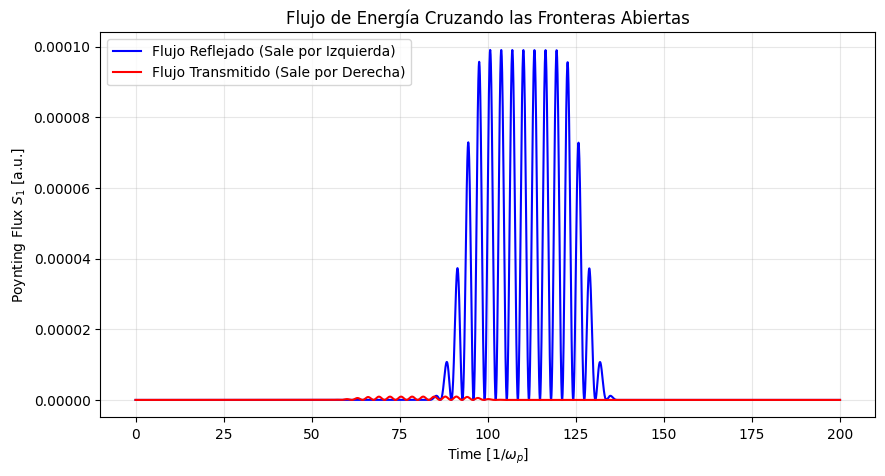

In [5]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson

# Ruta base a tus diagnósticos
base_path = '/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/double particles/MS/FLD/'

# ====================================================================
# 1. CALCULAR ENERGÍA INCIDENTE (Integral Espacial en t=0)
# ====================================================================
file_e2_0 = base_path + 'e2/e2-000000.h5'
file_b3_0 = base_path + 'b3/b3-000000.h5'

with h5py.File(file_e2_0, "r") as f:
    E_inc = np.copy(f['e2'])
    x_bounds = f['AXIS/AXIS1'][:]

with h5py.File(file_b3_0, "r") as f:
    B_inc = np.copy(f['b3'])

dx = (x_bounds[1] - x_bounds[0]) / len(E_inc)

# FACTOR CRÍTICO: 0.5 para que empate con el flujo de Poynting
U_density_inc = 0.5 * (E_inc**2 + B_inc**2)
Total_Inc = simpson(y=U_density_inc, dx=dx)


# ====================================================================
# 2. CALCULAR ENERGÍA REFLEJADA Y TRANSMITIDA (Integral Temporal de S1)
# ====================================================================
num_files = 5001
dt_dump = 0.04 # Tiempo físico entre cada archivo
time_array = np.linspace(0, (num_files-1)*dt_dump, num_files)

s1_left = np.zeros(num_files)
s1_right = np.zeros(num_files)

print("Leyendo archivos de Poynting (esto tomará unos segundos)...")
for i in range(num_files):
    # Generar nombre del archivo con 6 dígitos
    filename = base_path + f's1/s1-{i:06d}.h5'
    try:
        with h5py.File(filename, "r") as f:
            s1_data = f['s1'][:]
            # Extraer solo el valor en las fronteras
            s1_left[i] = s1_data[0]       # x = 0
            s1_right[i] = s1_data[-1]     # x = 110
    except Exception as e:
        print(f"Error leyendo {filename}. Saltando...")
        break

# Integración en el tiempo usando simpson y dt_dump
Total_Ref = simpson(y=-s1_left, dx=dt_dump)
Total_Trans = simpson(y=s1_right, dx=dt_dump)


# ====================================================================
# 3. RESULTADOS
# ====================================================================
R = Total_Ref / Total_Inc
T = Total_Trans / Total_Inc
Loss = 1.0 - (R + T)

print("=" * 50)
print("INTEGRACIÓN POR FLUJO DE POYNTING (Independiente de la caja)")
print(f"REFLECTANCIA (R):     {R:.4f}  ({R*100:.2f}%)")
print(f"TRANSMITANCIA (T):    {T:.4f}  ({T*100:.2f}%)")
print("-" * 50)
print(f"SUMA TOTAL (R+T):     {R+T:.4f}  ({(R+T)*100:.2f}%)")
print(f"ABSORCIÓN (Real):     {Loss:.4f}  ({Loss*100:.2f}%)")
print("=" * 50)

# Graficar los pulsos cruzando las fronteras
plt.figure(figsize=(10, 5))
plt.plot(time_array, -s1_left, label='Flujo Reflejado (Sale por Izquierda)', color='blue')
plt.plot(time_array, s1_right, label='Flujo Transmitido (Sale por Derecha)', color='red')
plt.xlabel('Time $[1/\omega_p]$')
plt.ylabel('Poynting Flux $S_1$ [a.u.]')
plt.title('Flujo de Energía Cruzando las Fronteras Abiertas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:78: SyntaxWarning: invalid escape sequence '\o'
<>:78: SyntaxWarning: invalid escape sequence '\o'
/var/folders/r1/8fnw2qyd6vs6x4fvg2cghqzh0000gn/T/ipykernel_4002/437216359.py:78: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Time $[1/\omega_p]$')


Leyendo archivos de Poynting (esto tomará unos segundos)...
INTEGRACIÓN POR FLUJO DE POYNTING (Independiente de la caja)
REFLECTANCIA (R):     0.9907  (99.07%)
TRANSMITANCIA (T):    0.0093  (0.93%)
--------------------------------------------------
SUMA TOTAL (R+T):     1.0000  (100.00%)
ABSORCIÓN (Real):     -0.0000  (-0.00%)


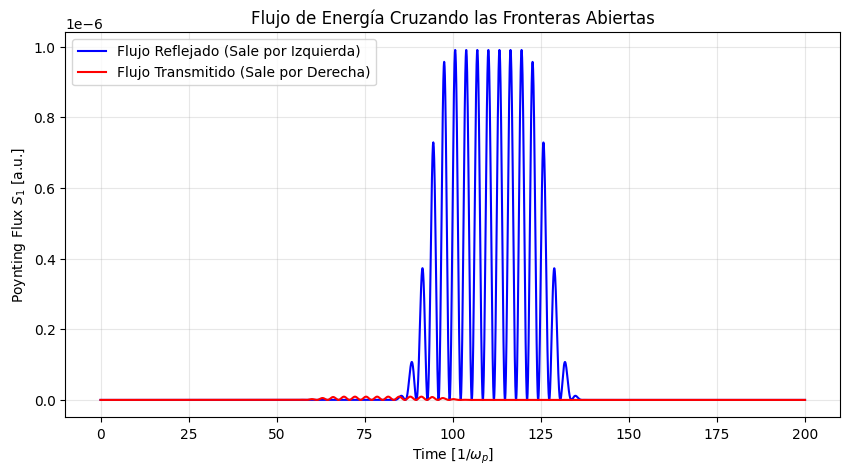

In [6]:
import h5py
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson

# Ruta base a tus diagnósticos
base_path = '/Users/beveridog1999/Documents/GoLP/osiris_project/simulations/plasma mirror/Dirac plasma slab/n=2000_d=0.01/lower_ponderomotive/MS/FLD/'

# ====================================================================
# 1. CALCULAR ENERGÍA INCIDENTE (Integral Espacial en t=0)
# ====================================================================
file_e2_0 = base_path + 'e2/e2-000000.h5'
file_b3_0 = base_path + 'b3/b3-000000.h5'

with h5py.File(file_e2_0, "r") as f:
    E_inc = np.copy(f['e2'])
    x_bounds = f['AXIS/AXIS1'][:]

with h5py.File(file_b3_0, "r") as f:
    B_inc = np.copy(f['b3'])

dx = (x_bounds[1] - x_bounds[0]) / len(E_inc)

# FACTOR CRÍTICO: 0.5 para que empate con el flujo de Poynting
U_density_inc = 0.5 * (E_inc**2 + B_inc**2)
Total_Inc = simpson(y=U_density_inc, dx=dx)


# ====================================================================
# 2. CALCULAR ENERGÍA REFLEJADA Y TRANSMITIDA (Integral Temporal de S1)
# ====================================================================
num_files = 5001
dt_dump = 0.04 # Tiempo físico entre cada archivo
time_array = np.linspace(0, (num_files-1)*dt_dump, num_files)

s1_left = np.zeros(num_files)
s1_right = np.zeros(num_files)

print("Leyendo archivos de Poynting (esto tomará unos segundos)...")
for i in range(num_files):
    # Generar nombre del archivo con 6 dígitos
    filename = base_path + f's1/s1-{i:06d}.h5'
    try:
        with h5py.File(filename, "r") as f:
            s1_data = f['s1'][:]
            # Extraer solo el valor en las fronteras
            s1_left[i] = s1_data[0]       # x = 0
            s1_right[i] = s1_data[-1]     # x = 110
    except Exception as e:
        print(f"Error leyendo {filename}. Saltando...")
        break

# Integración en el tiempo usando simpson y dt_dump
Total_Ref = simpson(y=-s1_left, dx=dt_dump)
Total_Trans = simpson(y=s1_right, dx=dt_dump)


# ====================================================================
# 3. RESULTADOS
# ====================================================================
R = Total_Ref / Total_Inc
T = Total_Trans / Total_Inc
Loss = 1.0 - (R + T)

print("=" * 50)
print("INTEGRACIÓN POR FLUJO DE POYNTING (Independiente de la caja)")
print(f"REFLECTANCIA (R):     {R:.4f}  ({R*100:.2f}%)")
print(f"TRANSMITANCIA (T):    {T:.4f}  ({T*100:.2f}%)")
print("-" * 50)
print(f"SUMA TOTAL (R+T):     {R+T:.4f}  ({(R+T)*100:.2f}%)")
print(f"ABSORCIÓN (Real):     {Loss:.4f}  ({Loss*100:.2f}%)")
print("=" * 50)

# Graficar los pulsos cruzando las fronteras
plt.figure(figsize=(10, 5))
plt.plot(time_array, -s1_left, label='Flujo Reflejado (Sale por Izquierda)', color='blue')
plt.plot(time_array, s1_right, label='Flujo Transmitido (Sale por Derecha)', color='red')
plt.xlabel('Time $[1/\omega_p]$')
plt.ylabel('Poynting Flux $S_1$ [a.u.]')
plt.title('Flujo de Energía Cruzando las Fronteras Abiertas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()